# 데이터 분석 실습 프로젝트

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib                 # 그래프 한글 폰트 자동 적용
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

print("준비 완료 - numpy", np.__version__, "/ pandas", pd.__version__, "/ seaborn", sns.__version__)

준비 완료 - numpy 2.5.1 / pandas 3.0.3 / seaborn 0.13.2


In [69]:
path = r'C:\Users\sb730\Desktop\NVIDIA교육\실습 자료\netflix_titles.csv'
df = pd.read_csv(path, encoding = 'utf-8')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [70]:
print(df.info(),'\n')
print(df.describe)

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.4 MB
None 

<bound method NDFrame.describe of      show_id     type                                    title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                     7:19   
2         s3    Movie                       

In [71]:
# (1) 넷플릭스가 신작을 가장 많이 출시하는 달은?
df_month = df.dropna(subset=['date_added'])
df_month['release_month'] = df_month['date_added'].str.strip().str.split(' ').str[0]
df_month.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,release_month
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,August
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,December
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",December
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",November
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,January


In [72]:
month_cnt = df_month['release_month'].value_counts()
month_cnt

release_month
December     833
October      785
January      757
November     738
March        669
September    619
August       618
April        601
July         600
May          543
June         542
February     472
Name: count, dtype: int64

<Axes: xlabel='release_month', ylabel='count'>

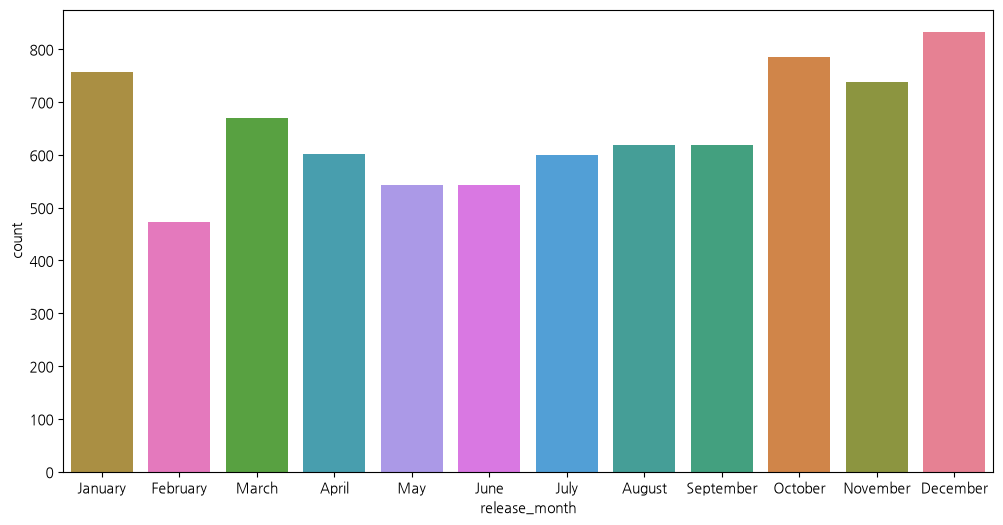

In [73]:
month_df = month_cnt.to_frame()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize = (12, 6))
sns.barplot(data = month_df, x = 'release_month', y = 'count', hue = 'release_month', order = month_order)

<Axes: xlabel='rating', ylabel='count'>

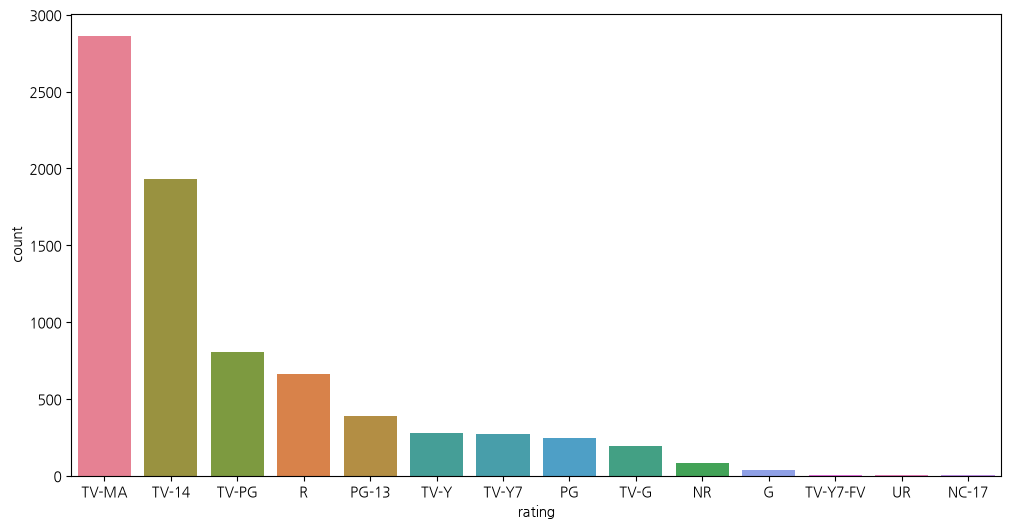

In [84]:
# (2) 관람 등급에 따른 컨텐츠 개수
df_rate = df.dropna(subset=['rating'])
order_by_cnt = df_rate['rating'].value_counts().index

plt.figure(figsize = (12,6))
sns.countplot(data = df, x = 'rating', hue = 'rating', legend = False, order = order_by_cnt)

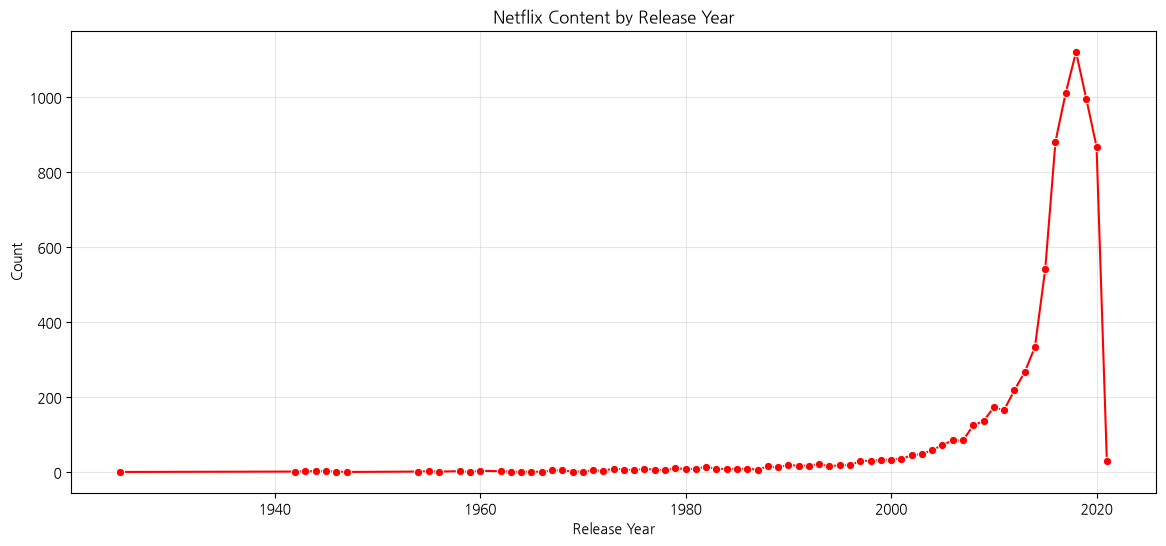

In [85]:
# (3) 넷플릭스 콘텐츠 연도별 증가량
year_cnt = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
sns.lineplot(x=year_cnt.index, y=year_cnt.values, marker='o', color='red')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.title('Netflix Content by Release Year')
plt.grid(True, alpha=0.3)
plt.show()

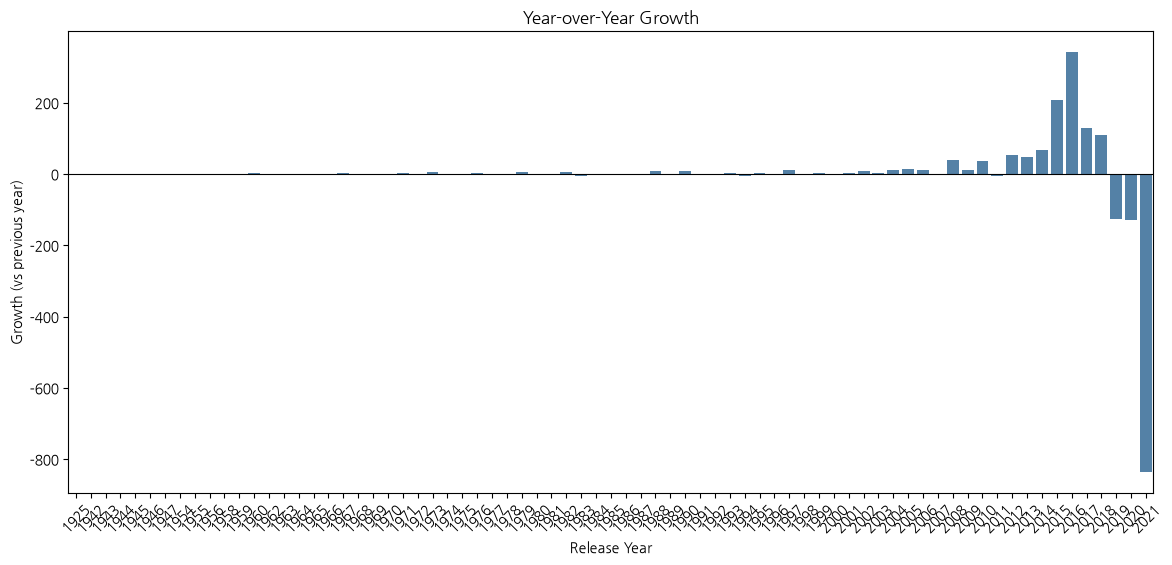

In [86]:
year_cnt = df['release_year'].value_counts().sort_index()
year_growth = year_cnt.diff()   # 전년 대비 증가량

plt.figure(figsize=(14, 6))
sns.barplot(x=year_growth.index, y=year_growth.values, color='steelblue')
plt.xticks(rotation=45)
plt.xlabel('Release Year')
plt.ylabel('Growth (vs previous year)')
plt.title('Year-over-Year Growth')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

<Axes: xlabel='type', ylabel='count'>

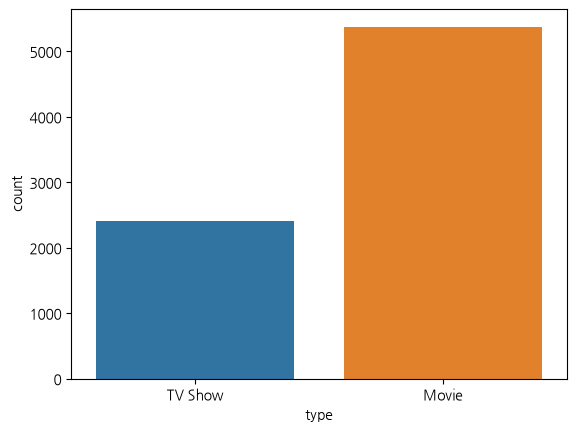

In [89]:
# (4) 넷플릭스 출시작 개수 비교 영화 vs 드라마
sns.countplot(data = df, x = 'type', hue = 'type')

In [93]:
# (5) 국가별 러닝타임
df_country = df[['country', 'duration']].dropna(subset = ['country'])
df_country

,country,duration
0,Brazil,4 Seasons
1,Mexico,93 min
2,Singapore,78 min
3,United States,80 min
4,United States,123 min
...,...,...
7781,United States,88 min
7782,"Sweden, Czech Republic, United Kingdom, Denmar...",99 min
7783,India,111 min
7785,Australia,1 Season


In [94]:
df_country = df_country[~df_country['duration'].str.contains('Season')]
df_country

,country,duration
1,Mexico,93 min
2,Singapore,78 min
3,United States,80 min
4,United States,123 min
6,Egypt,95 min
...,...,...
7780,India,94 min
7781,United States,88 min
7782,"Sweden, Czech Republic, United Kingdom, Denmar...",99 min
7783,India,111 min


In [96]:
# 1. 콤마로 구분된 country를 리스트로 쪼개기
df_country['country'] = df_country['country'].str.split(', ')

# 2. 리스트를 각각의 행으로 펼치기 (explode)
df_country = df_country.explode('country')

df_country.tail()

,country,duration
7782,Netherlands,99 min
7783,India,111 min
7786,United Kingdom,90 min
7786,Canada,90 min
7786,United States,90 min


In [97]:
df_country['duration_min'] = df_country['duration'].str.replace(' min', '').astype(int)

df_country.groupby('country')['duration_min'].mean().sort_values(ascending=False)

country
Liechtenstein    200.000000
Montenegro       157.000000
Soviet Union     156.666667
Bahamas          145.000000
Morocco          137.333333
                    ...    
Georgia           71.500000
Namibia           69.500000
Guatemala         68.000000
Uganda            68.000000
Kazakhstan        67.000000
Name: duration_min, Length: 114, dtype: float64

<Axes: xlabel='count', ylabel='country'>

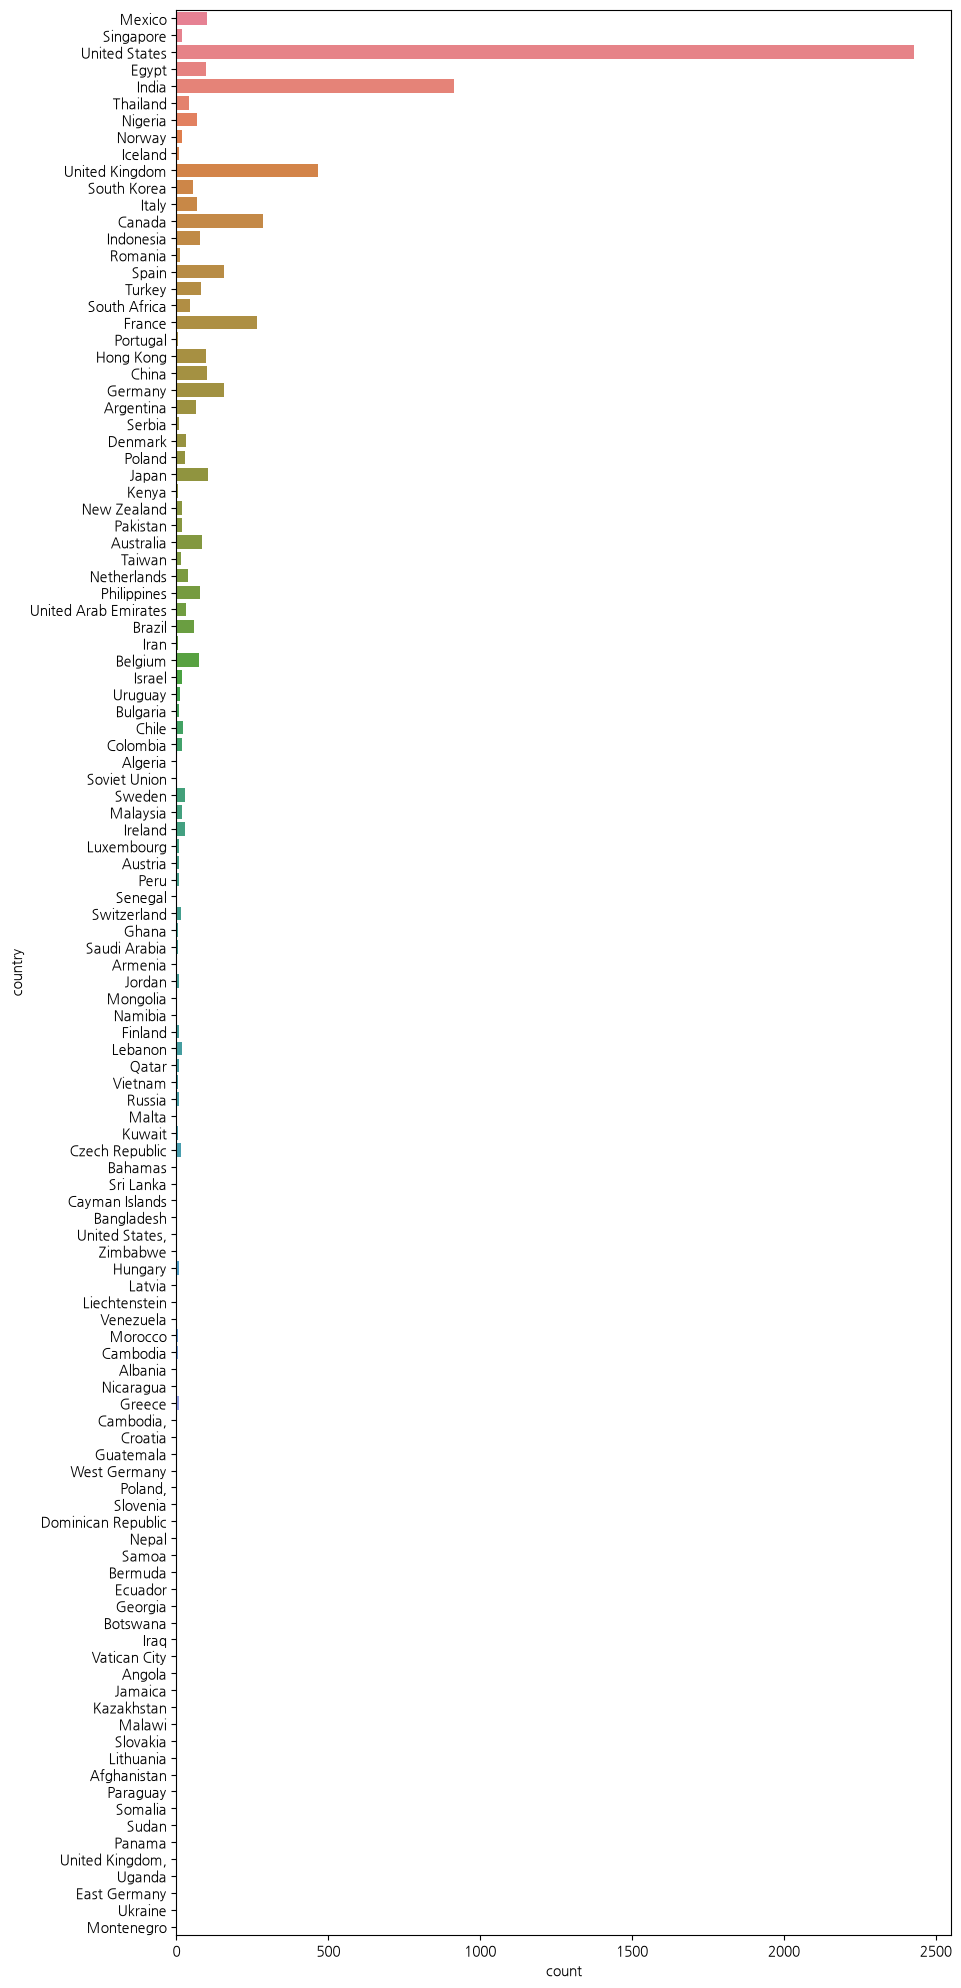

In [100]:
plt.figure(figsize=(10,25))
sns.countplot(data = df_country, y = 'country', hue = 'country')

In [101]:
# (5) 한국 콘텐츠 중 글로벌 Top 10
df_korea = df[df['country'] == 'South Korea']
df_korea

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
27,s28,Movie,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,"September 8, 2020",2020,TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ..."
51,s52,TV Show,100 Days My Prince,NaN,"Doh Kyung-soo, Nam Ji-hyun, Cho Seong-ha, Cho ...",South Korea,"December 7, 2020",2018,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Upon losing his memory, a crown prince encount..."
61,s62,TV Show,12 Years Promise,NaN,"So-yeon Lee, Namkoong Min, Tae-im Lee, So-hui ...",South Korea,"May 22, 2017",2014,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",A pregnant teen is forced by her family to lea...
81,s82,Movie,2015 Dream Concert,NaN,"4Minute, B1A4, BtoB, ELSIE, EXID, EXO, Got7, I...",South Korea,"April 28, 2017",2015,TV-PG,107 min,"International Movies, Music & Musicals",The world's biggest K-pop festival marked its ...
91,s92,Movie,26 Years,Geun-hyun Cho,"Goo Jin, Hye-jin Han, Soo-bin Bae, Seul-ong Im...",South Korea,"October 1, 2017",2012,TV-MA,135 min,"Dramas, International Movies, Thrillers",Twenty-six years after the 1980 massacre at Gw...
...,...,...,...,...,...,...,...,...,...,...,...,...
7583,s7584,TV Show,When the Camellia Blooms,NaN,"Kong Hyo-jin, Kang Ha-neul, Kim Ji-seok, Oh Ju...",South Korea,"September 18, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Dongbaek is a single mother. When a potential ...
7601,s7602,TV Show,White Nights,NaN,"Yo-Won Lee, Goo Jin, U-ie, Hae-in Jung, Gook-h...",South Korea,"February 14, 2017",2016,TV-14,1 Season,"International TV Shows, Korean TV Shows, TV Dr...","A coldhearted heiress, a man from her past and..."
7711,s7712,TV Show,YG Future Strategy Office,NaN,"Seungri, Yoo Byung Jae, Lee Jai-jin, Jinu, Son...",South Korea,"October 5, 2018",2018,TV-MA,1 Season,"International TV Shows, Korean TV Shows, TV Co...","K-pop star Seungri, BIGBANG's youngest member,..."
7718,s7719,Movie,Yoo Byung Jae: Discomfort Zone,Y. Joon Chung,Yoo Byung Jae,South Korea,"August 17, 2018",2018,TV-MA,54 min,Stand-Up Comedy,Daring comedian Yoo Byung-jae connects critici...
